In [115]:
import pandas as pd

df = pd.read_csv('https://drive.google.com/uc?id=1XZbZ5Z7MBXYaR3UO1HbQ4ncPi4R3HsyF')
df.head();

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [117]:
df.loc[df.name == 'grapefruit', 'name'] = 0
df.loc[df.name == 'orange', 'name'] = 1

In [118]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
df['name'] = label_encoder.fit_transform(df['name'])
print(df)

      name  diameter  weight  red  green  blue
0        1      2.96   86.76  172     85     2
1        1      3.91   88.05  166     78     3
2        1      4.42   95.17  156     81     2
3        1      4.47   95.60  163     81     4
4        1      4.48   95.76  161     72     9
...    ...       ...     ...  ...    ...   ...
9995     0     15.35  253.89  149     77    20
9996     0     15.41  254.67  148     68     7
9997     0     15.59  256.50  168     82    20
9998     0     15.92  260.14  142     72    11
9999     0     16.45  261.51  152     74     2

[10000 rows x 6 columns]


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  int64  
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 468.9 KB


In [120]:
dataset=df.values;

In [121]:
X = dataset[:,1:6]

In [122]:
y=dataset[:,0]

In [123]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X_Scale = min_max_scaler.fit_transform(X)
X_Scale

array([[0.        , 0.        , 0.74025974, 0.63529412, 0.        ],
       [0.07042254, 0.00738197, 0.66233766, 0.55294118, 0.01851852],
       [0.10822832, 0.04812589, 0.53246753, 0.58823529, 0.        ],
       ...,
       [0.93624907, 0.97133047, 0.68831169, 0.6       , 0.33333333],
       [0.96071164, 0.99216023, 0.35064935, 0.48235294, 0.16666667],
       [1.        , 1.        , 0.48051948, 0.50588235, 0.        ]])

In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_Scale, y, test_size=0.3)

In [125]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(5,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/Users/yutaaa/Developments/deep_learning/venv_tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.7397 - loss: 0.6640
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - accuracy: 0.8863 - loss: 0.5906
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.9177 - loss: 0.5043
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.9237 - loss: 0.4088
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - accuracy: 0.9266 - loss: 0.3267
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.9274 - loss: 0.2700
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.9277 - loss: 0.2350
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.9287 - loss: 0.2138
Epoch 9/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.9293 - loss: 0.2012
Epoch 10/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - accuracy: 0.9294 - loss: 0.1933
Epoch 11/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - accuracy: 0.9293 - loss: 0.1874
Epoch 12/100
219/21

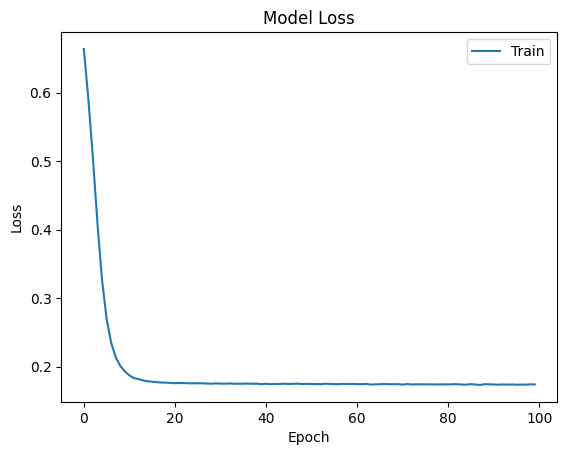

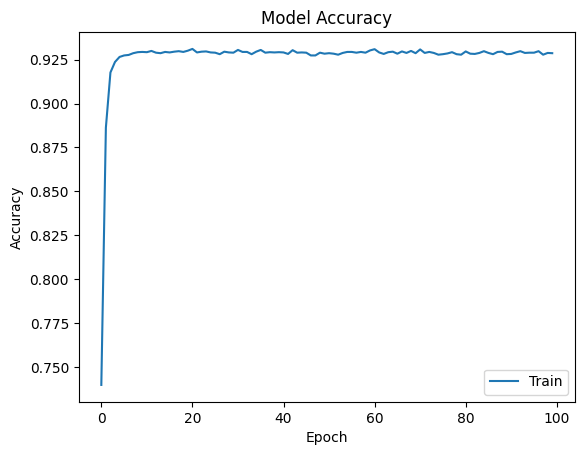

In [126]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import hist
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit(X_train, Y_train, epochs=100)


plt.plot(hist.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')
plt.show()

plt.plot(hist.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='lower right')
plt.show()

In [127]:
model.evaluate(X_test, Y_test, batch_size=1)

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 2s 577us/step - accuracy: 0.9233 - loss: 0.1858


[0.1857772022485733, 0.9233333468437195]